# Random-network degrees versus a heavy tail

This is a read-the-figure exercise for a random network with $\langle k \rangle = 10$. The random-network curve is a Poisson distribution. The comparison curve is an illustrative discrete power law, $P(k) \propto k^{-\gamma}$ for $k \geq k_{\min}$—a heavy-tailed distribution, not a fit to data.

Use the controls to change the heavy tail. On **linear axes**, look for the random network's narrow concentration around 10 versus a distribution that leaves appreciable probability far to the right. On **log–log axes**, the power-law tail is approximately straight, while the Poisson tail bends sharply down and disappears. A straight-looking tail is a visual clue, not by itself evidence that empirical data follow a power law.

Matplotlib is building the font cache; this may take a moment.


Output()

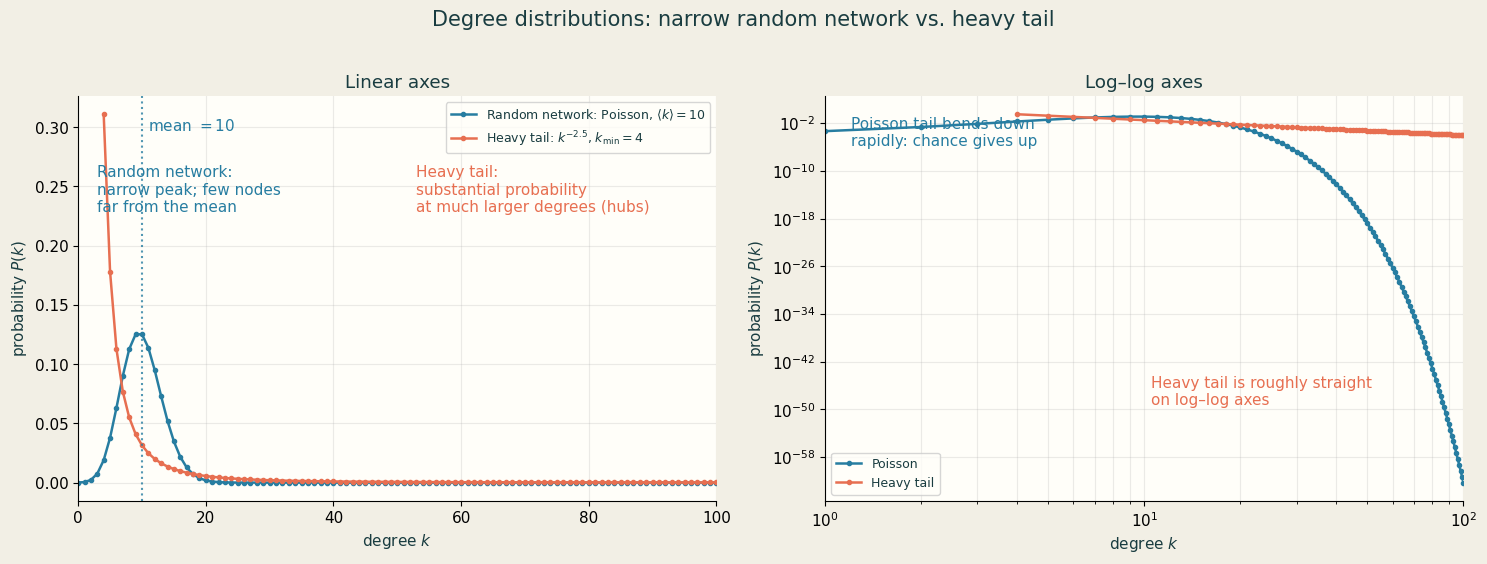

In [1]:
import math

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

plt.rcParams.update({"figure.facecolor": "#f2efe5", "axes.facecolor": "#fffef9", "axes.spines.top": False, "axes.spines.right": False, "axes.labelcolor": "#193c40", "text.color": "#193c40", "font.size": 11})


def poisson_pmf(k, mean):
    """Poisson probabilities computed recursively, so SciPy is not required."""
    probabilities = np.empty(len(k), dtype=float)
    probabilities[0] = math.exp(-mean)
    for degree in range(1, len(k)):
        probabilities[degree] = probabilities[degree - 1] * mean / degree
    return probabilities


def power_law_pmf(k, gamma, k_min):
    """A discrete power law, normalized far beyond the displayed range."""
    normalizer_degrees = np.arange(k_min, 100_001, dtype=float)
    normalizer = np.sum(normalizer_degrees ** (-gamma))
    probabilities = np.zeros_like(k, dtype=float)
    tail = k >= k_min
    probabilities[tail] = k[tail] ** (-gamma) / normalizer
    return probabilities


def draw_degree_distributions(gamma=2.5, k_min=4, max_degree=100):
    mean_degree = 10
    degrees = np.arange(max_degree + 1, dtype=float)
    poisson = poisson_pmf(degrees, mean_degree)
    heavy_tail = power_law_pmf(degrees, gamma, k_min)

    fig, (linear_ax, log_ax) = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle("Degree distributions: narrow random network vs. heavy tail", fontsize=15, y=1.02)

    linear_ax.plot(degrees, poisson, "o-", ms=3, lw=1.8, color="#277da1",
                   label=r"Random network: Poisson, $\langle k \rangle=10$")
    linear_ax.plot(degrees[degrees >= k_min], heavy_tail[degrees >= k_min], "o-", ms=3, lw=1.8,
                   color="#e76f51", label=rf"Heavy tail: $k^{{-{gamma:.1f}}}$, $k_{{\min}}={k_min}$")
    linear_ax.axvline(mean_degree, color="#277da1", ls=":", alpha=0.8)
    linear_ax.text(mean_degree + 1, linear_ax.get_ylim()[1] * 0.91, r"mean $=10$", color="#277da1")
    linear_ax.text(0.03, 0.83, "Random network:\nnarrow peak; few nodes\nfar from the mean",
                   transform=linear_ax.transAxes, color="#277da1", va="top")
    linear_ax.text(0.53, 0.83, "Heavy tail:\nsubstantial probability\nat much larger degrees (hubs)",
                   transform=linear_ax.transAxes, color="#e76f51", va="top")
    linear_ax.set(title="Linear axes", xlabel="degree $k$", ylabel="probability $P(k)$", xlim=(0, max_degree))
    linear_ax.legend(fontsize=9)
    linear_ax.grid(alpha=0.25)

    positive_poisson = (degrees > 0) & (poisson > 0)
    positive_heavy = (degrees >= k_min) & (heavy_tail > 0)
    log_ax.loglog(degrees[positive_poisson], poisson[positive_poisson], "o-", ms=3, lw=1.8, color="#277da1",
                  label="Poisson")
    log_ax.loglog(degrees[positive_heavy], heavy_tail[positive_heavy], "o-", ms=3, lw=1.8, color="#e76f51",
                  label="Heavy tail")
    log_ax.text(0.04, 0.95, "Poisson tail bends down\nrapidly: chance gives up",
                transform=log_ax.transAxes, color="#277da1", va="top")
    log_ax.text(0.51, 0.23, "Heavy tail is roughly straight\non log–log axes",
                transform=log_ax.transAxes, color="#e76f51", va="bottom")
    log_ax.set(title="Log–log axes", xlabel="degree $k$", ylabel="probability $P(k)$", xlim=(1, max_degree))
    log_ax.legend(fontsize=9)
    log_ax.grid(which="both", alpha=0.25)

    fig.tight_layout()
    plt.show()


gamma_slider = widgets.FloatSlider(value=2.5, min=2.1, max=4.0, step=0.1, description=r"Tail exponent $\gamma$:",
                                   continuous_update=False, readout_format=".1f")
k_min_slider = widgets.IntSlider(value=4, min=1, max=10, step=1, description=r"Tail start $k_{\min}$:",
                                   continuous_update=False)
max_degree_slider = widgets.IntSlider(value=100, min=30, max=500, step=10, description="Show degrees through:",
                                        continuous_update=False)

controls = widgets.VBox([gamma_slider, k_min_slider, max_degree_slider])
plot = widgets.interactive_output(
    draw_degree_distributions,
    {"gamma": gamma_slider, "k_min": k_min_slider, "max_degree": max_degree_slider},
)
display(controls, plot)

# Static preview also remains visible in notebook viewers without widgets.
draw_degree_distributions()


## Exercise 2.4.2 — Reproduce the Watts–Strogatz figure

For each rewiring probability $q$, generate 50 Watts–Strogatz networks with $n=500$ and $\langle k\rangle=4$. The code reports the raw mean and sample standard deviation of the mean shortest path $\langle d\rangle$ and average clustering $C$. The plot normalizes both metrics by their value at $q=0$, as in the classic Watts–Strogatz comparison.

An ordinary logarithmic axis cannot contain $q=0$, so the plot uses a symmetric-log axis: zero is shown explicitly and the positive values are spaced logarithmically.

    q    <d> mean    <d> std     C mean      C std
 0.00      62.876      0.000      0.500      0.000
 0.01      25.662      5.016      0.488      0.004
 0.03      13.115      1.050      0.460      0.007
 0.05      10.342      0.674      0.435      0.009
 0.10       7.714      0.281      0.374      0.013
 0.20       6.131      0.106      0.270      0.014


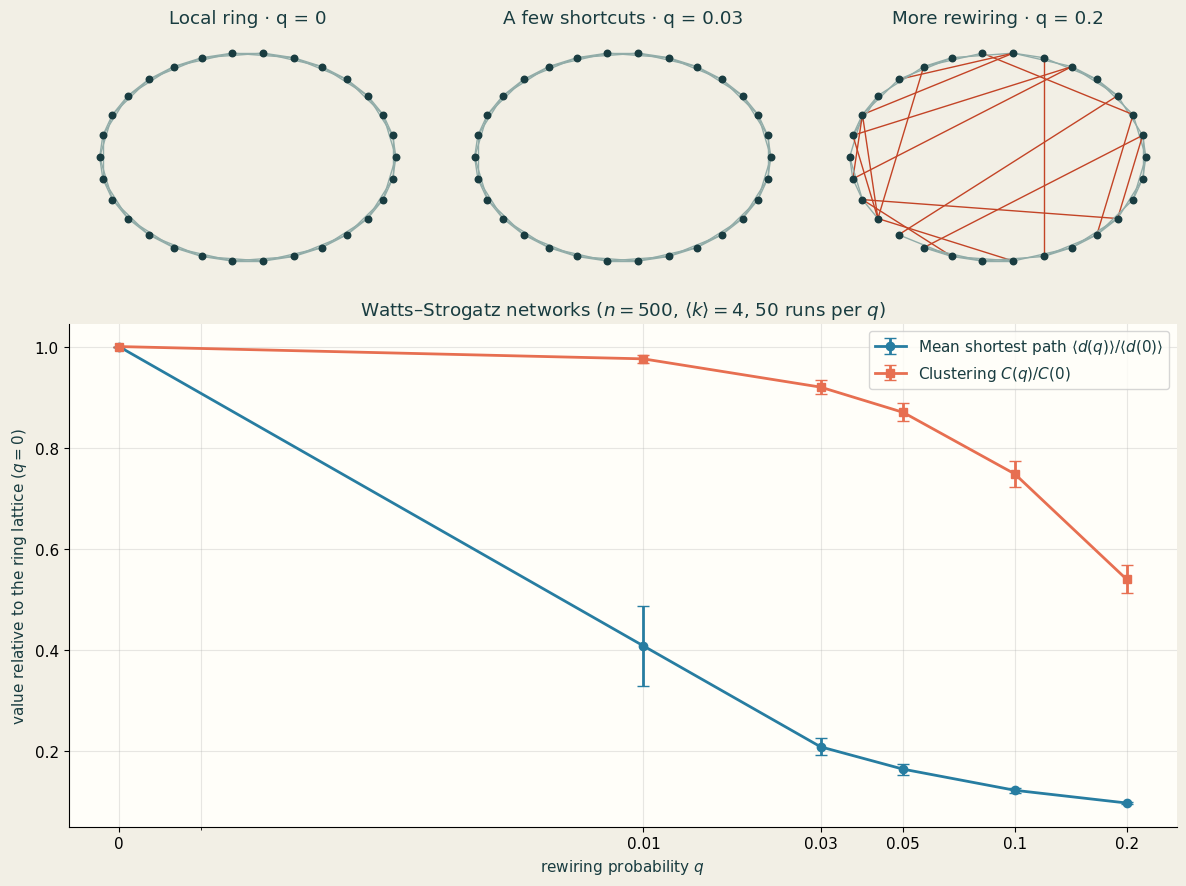

In [2]:
import networkx as nx


n = 500
mean_degree = 4
runs_per_q = 50
q_values = np.array([0, 0.01, 0.03, 0.05, 0.1, 0.2])

path_length_runs = np.empty((len(q_values), runs_per_q))
clustering_runs = np.empty((len(q_values), runs_per_q))

for q_index, q in enumerate(q_values):
    for run in range(runs_per_q):
        seed = q_index * runs_per_q + run
        graph = nx.watts_strogatz_graph(n, mean_degree, q, seed=seed)
        path_length_runs[q_index, run] = nx.average_shortest_path_length(graph)
        clustering_runs[q_index, run] = nx.average_clustering(graph)

mean_path_length = path_length_runs.mean(axis=1)
std_path_length = path_length_runs.std(axis=1, ddof=1)
mean_clustering = clustering_runs.mean(axis=1)
std_clustering = clustering_runs.std(axis=1, ddof=1)

print(f"{'q':>5}  {'<d> mean':>10}  {'<d> std':>9}  {'C mean':>9}  {'C std':>9}")
for q, path_mean, path_std, clustering_mean, clustering_std in zip(
    q_values, mean_path_length, std_path_length, mean_clustering, std_clustering
):
    print(f"{q:5.2f}  {path_mean:10.3f}  {path_std:9.3f}  {clustering_mean:9.3f}  {clustering_std:9.3f}")

normalized_path_length = mean_path_length / mean_path_length[0]
normalized_clustering = mean_clustering / mean_clustering[0]
normalized_path_error = std_path_length / mean_path_length[0]
normalized_clustering_error = std_clustering / mean_clustering[0]

fig = plt.figure(figsize=(12, 9))
grid = fig.add_gridspec(2, 3, height_ratios=[1, 2])
for column, q_example in enumerate([0, 0.03, 0.2]):
    inset = fig.add_subplot(grid[0, column])
    example = nx.watts_strogatz_graph(30, 4, q_example, seed=7)
    positions = nx.circular_layout(example)
    ring_edges = {tuple(sorted(edge)) for edge in nx.watts_strogatz_graph(30, 4, 0).edges()}
    colors = ["#c34426" if tuple(sorted(edge)) not in ring_edges else "#91aca8" for edge in example.edges()]
    nx.draw_networkx(example, pos=positions, ax=inset, with_labels=False,
                     node_size=22, node_color="#193c40", edge_color=colors, width=1)
    inset.set_title(["Local ring · q = 0", "A few shortcuts · q = 0.03", "More rewiring · q = 0.2"][column])
    inset.set_axis_off()
ax = fig.add_subplot(grid[1, :])
ax.errorbar(
    q_values, normalized_path_length, yerr=normalized_path_error,
    fmt="o-", capsize=4, lw=2, color="#277da1",
    label=r"Mean shortest path $\langle d(q)\rangle / \langle d(0)\rangle$",
)
ax.errorbar(
    q_values, normalized_clustering, yerr=normalized_clustering_error,
    fmt="s-", capsize=4, lw=2, color="#e76f51",
    label=r"Clustering $C(q) / C(0)$",
)
ax.set_xscale("symlog", linthresh=0.005)
ax.set_xticks(q_values)
ax.set_xticklabels([f"{q:g}" for q in q_values])
ax.set(
    xlabel="rewiring probability $q$",
    ylabel="value relative to the ring lattice ($q=0$)",
    title=rf"Watts–Strogatz networks ($n={n}$, $\langle k\rangle={mean_degree}$, {runs_per_q} runs per $q$)",
)
ax.grid(which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


### At-a-glance answer

- **Random network:** one narrow peak near $k=10$ and a short tail; high-degree hubs are astronomically unlikely.
- **Heavy-tailed distribution:** probability declines slowly enough that very high degrees remain visible; hubs are plausible.
- **On log–log axes:** the Poisson tail curves downward, whereas this power-law example has a roughly straight tail.


CCDF values at observed degrees:
[(np.int64(0), np.float64(1.0)), (np.int64(1), np.float64(0.8085808580858086)), (np.int64(2), np.float64(0.6732673267326733)), (np.int64(3), np.float64(0.5313531353135313)), (np.int64(4), np.float64(0.4389438943894389)), (np.int64(5), np.float64(0.3696369636963696)), (np.int64(6), np.float64(0.297029702970297)), (np.int64(7), np.float64(0.25412541254125415)), (np.int64(8), np.float64(0.22112211221122113)), (np.int64(9), np.float64(0.19801980198019803)), (np.int64(10), np.float64(0.17491749174917492)), (np.int64(11), np.float64(0.15181518151815182)), (np.int64(12), np.float64(0.13861386138613863)), (np.int64(13), np.float64(0.12871287128712872)), (np.int64(14), np.float64(0.10891089108910891)), (np.int64(15), np.float64(0.10231023102310231)), (np.int64(16), np.float64(0.09570957095709572)), (np.int64(17), np.float64(0.0858085808580858)), (np.int64(19), np.float64(0.07260726072607261)), (np.int64(20), np.float64(0.06930693069306931)), (np.int64(21), np.fl

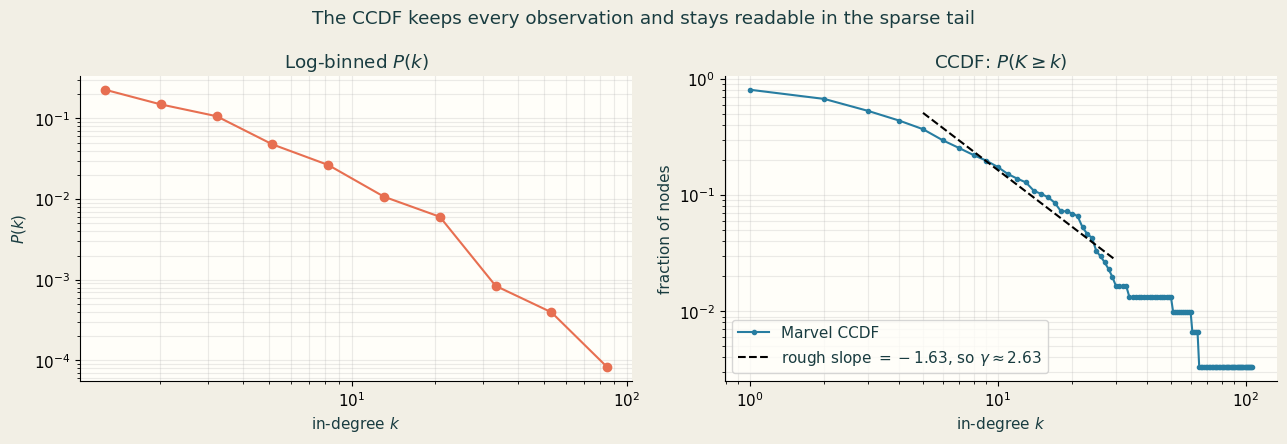

The CCDF needs no bins: each point directly counts the fraction of nodes with degree at least k.


In [3]:
# 2.6.1 - Marvel in-degree: binned P(k) versus the unbinned CCDF
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

data_dir = Path("data") if Path("data/week1_edges.tsv").exists() else Path("notebooks/data")
nodes = pd.read_csv(data_dir / "week1_nodes.tsv", sep="\t", comment="#", quoting=3)
edges = pd.read_csv(data_dir / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
marvel = nx.DiGraph()
marvel.add_nodes_from(nodes.node_id)
marvel.add_edges_from(edges.itertuples(index=False))
marvel_in_degree = np.array([degree for _, degree in marvel.in_degree()])

def ccdf(degrees):
    k = np.arange(1, max(degrees) + 1)
    return k, np.array([(degrees >= degree).mean() for degree in k])

marvel_k, marvel_ccdf = ccdf(marvel_in_degree)
bins = np.geomspace(1, marvel_in_degree.max() + 1, 11)
counts, edges_ = np.histogram(marvel_in_degree[marvel_in_degree > 0], bins=bins)
bin_centers = np.sqrt(edges_[:-1] * edges_[1:])
binned_pk = counts / (len(marvel_in_degree) * np.diff(edges_))

fit = (marvel_k >= 5) & (marvel_k <= 30)
slope, intercept = np.polyfit(np.log10(marvel_k[fit]), np.log10(marvel_ccdf[fit]), 1)
gamma_rough = 1 - slope  # CCDF slope = -(gamma - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
nonempty = counts > 0
axes[0].loglog(bin_centers[nonempty], binned_pk[nonempty], "o-", color="#e76f51")
axes[0].set(title="Log-binned $P(k)$", xlabel="in-degree $k$", ylabel="$P(k)$")
axes[1].loglog(marvel_k, marvel_ccdf, "o-", ms=3, color="#277da1", label="Marvel CCDF")
axes[1].loglog(marvel_k[fit], 10 ** (intercept + slope * np.log10(marvel_k[fit])), "--", color="black",
               label=rf"rough slope $={slope:.2f}$, so $\gamma\approx{gamma_rough:.2f}$")
axes[1].set(title=r"CCDF: $P(K \geq k)$", xlabel="in-degree $k$", ylabel="fraction of nodes")
axes[1].legend()
for ax in axes: ax.grid(which="both", alpha=0.25)
fig.suptitle("The CCDF keeps every observation and stays readable in the sparse tail")
unique_k = np.unique(marvel_in_degree)
unique_ccdf = np.array([(marvel_in_degree >= degree).mean() for degree in unique_k])

print("CCDF values at observed degrees:")
print(list(zip(unique_k, unique_ccdf)))

fig.tight_layout()
plt.show()
print("The CCDF needs no bins: each point directly counts the fraction of nodes with degree at least k.")


### How to read this comparison

Marvel uses **directed in-degree** on 303 articles; BA and its matched random baseline use **undirected degree** on 5,000 nodes. Their sizes and mean degrees differ. This figure illustrates shapes, rather than a controlled test of which model reproduces Marvel. A model-selection comparison should use consistent degree definitions and match network size and density before assessing fit.

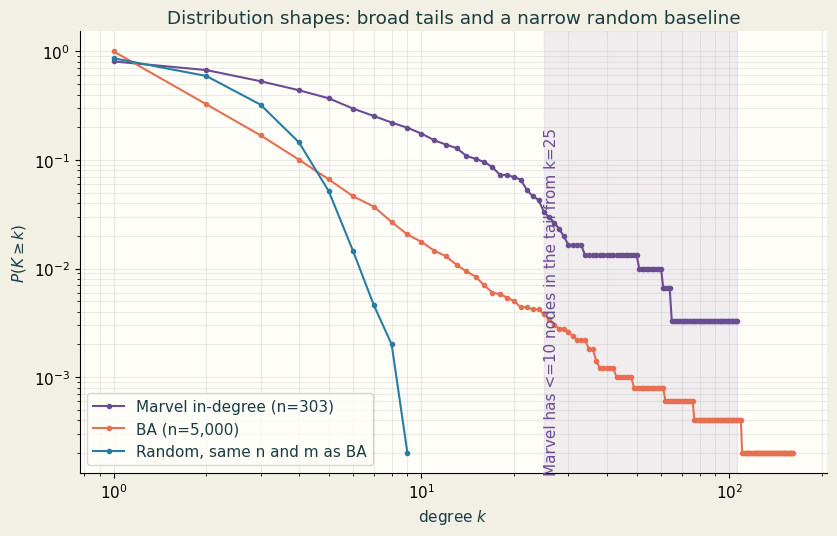

Marvel becomes visibly sparse/noisy around k=25; its 303 nodes cannot sample a smooth far tail.


In [4]:
# 2.6.2 - Marvel versus a 5,000-node BA network and a same-size random network
ba = nx.barabasi_albert_graph(5_000, 1, seed=7)
random_graph = nx.gnm_random_graph(ba.number_of_nodes(), ba.number_of_edges(), seed=7)
ba_degree = np.array([degree for _, degree in ba.degree()])
random_degree = np.array([degree for _, degree in random_graph.degree()])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for degrees, label, color in [
    (marvel_in_degree, "Marvel in-degree (n=303)", "#6a4c93"),
    (ba_degree, "BA (n=5,000)", "#e76f51"),
    (random_degree, "Random, same n and m as BA", "#277da1"),
]:
    k, probability = ccdf(degrees)
    ax.loglog(k, probability, "o-", ms=3, lw=1.5, label=label, color=color)

sparse_tail_start = marvel_k[np.flatnonzero(marvel_ccdf * len(marvel_in_degree) <= 10)[0]]
ax.axvspan(sparse_tail_start, marvel_k[-1], color="#6a4c93", alpha=0.09)
ax.text(sparse_tail_start, 0.2, f"Marvel has <=10 nodes in the tail from k={sparse_tail_start}",
        color="#6a4c93", rotation=90, va="top")
ax.set(title="Distribution shapes: broad tails and a narrow random baseline",
       xlabel="degree $k$", ylabel=r"$P(K \geq k)$")
ax.grid(which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()
print(f"Marvel becomes visibly sparse/noisy around k={sparse_tail_start}; its 303 nodes cannot sample a smooth far tail.")


In [5]:
# 2.6.3 - Copy this into a fresh LLM chat, then grade the answers
observed_k = np.unique(marvel_in_degree[marvel_in_degree > 0])
ccdf_values = [(int(k), round(float((marvel_in_degree >= k).mean()), 4)) for k in observed_k]

print("PROMPT 1:\nHere are (k, P(K >= k)) CCDF values:\n", ccdf_values)
print("\nIs this network scale-free?")
print("\nPROMPT 2:\nHow would you test that properly?")
print("""
GRADE THE ANSWER
Good: distinguishes heavy-tailed from power-law; asks for a fitted k_min and exponent,
a goodness-of-fit test, and comparison with alternatives such as log-normal or cutoff power law.
Red flag: declares 'scale-free' just because the log-log plot looks straight.

Best wrong sentence: ________________________________________________""")


PROMPT 1:
Here are (k, P(K >= k)) CCDF values:
 [(1, 0.8086), (2, 0.6733), (3, 0.5314), (4, 0.4389), (5, 0.3696), (6, 0.297), (7, 0.2541), (8, 0.2211), (9, 0.198), (10, 0.1749), (11, 0.1518), (12, 0.1386), (13, 0.1287), (14, 0.1089), (15, 0.1023), (16, 0.0957), (17, 0.0858), (19, 0.0726), (20, 0.0693), (21, 0.066), (22, 0.0528), (23, 0.0462), (24, 0.0429), (25, 0.033), (26, 0.0297), (27, 0.0264), (28, 0.0231), (29, 0.0198), (33, 0.0165), (50, 0.0132), (60, 0.0099), (64, 0.0066), (106, 0.0033)]

Is this network scale-free?

PROMPT 2:
How would you test that properly?

GRADE THE ANSWER
Good: distinguishes heavy-tailed from power-law; asks for a fitted k_min and exponent,
a goodness-of-fit test, and comparison with alternatives such as log-normal or cutoff power law.
Red flag: declares 'scale-free' just because the log-log plot looks straight.

Best wrong sentence: ________________________________________________


### 2.6.4 — The robust conclusion

The robust claim is that the Marvel in-degree distribution is **heavy-tailed**: most characters receive few links, while a small number are hubs with much larger in-degree, and its CCDF extends well beyond the displayed random-network example. That example matches the BA network, not Marvel, so this is a qualitative shape comparison. From these plots alone, however, we cannot claim that Marvel is scale-free or that its tail follows a pure power law with a particular $\gamma$; the rough slope is only an eyeball estimate and the tail contains very few of the 303 characters. Establishing the stronger claim would require choosing $k_{\min}$, estimating $\gamma$ by maximum likelihood, testing goodness of fit on synthetic data, and comparing the fit against plausible alternatives such as a log-normal or a power law with an exponential cutoff.